In [1]:
import os
os.chdir("..")
print(os.getcwd())

D:\repositories\PyFlowSolver


In [2]:
%run .\pyflowsolver\volumeManager.py
%run .\pyflowsolver\sparseArray.py
%run .\pyflowsolver\fastLaplacian.py
%run .\pyflowsolver\darcySolver.py

In [3]:
import porespy as ps

In [4]:
PORE = 1
INLET = 2
OUTLET = 3

In [5]:
'''
vol = ps.generators.blobs(shape=(20, 20, 20), blobiness=0.4, porosity=0.55).astype(np.uint8)
vol[1, 5:25, 5:10] = INLET
vol[2, 5:25, 13:19] = INLET
vol[17, 5:25, 3:19] = OUTLET
'''
vol = np.ones((5,5,5), dtype=np.uint8)
vol[:,0,:] = 2
vol[:, -1, :] = 3
vol[2, 2, 2] = 0

In [6]:
import numpy as np
import scipy as sc
from numba import njit

In [7]:
lab, n_lab = sc.ndimage.label(vol)

In [8]:
@njit
def filter_connected_volume(volume, labels):
    w, h, d = volume.shape
    inlet_set = set()
    outlet_set = set()
    for i in range(w):
        for j in range(h):
            for k in range(d):
                if volume[i, j, k] == INLET:
                    label = labels[i, j, k]
                    if label != 0:
                        inlet_set.add(label)
                elif volume[i, j, k] == OUTLET:
                    label = labels[i, j, k]
                    if label != 0:
                        outlet_set.add(label)
    connected_labels = inlet_set.intersection(outlet_set)
    for i in range(w):
        for j in range(h):
            for k in range(d):
                if labels[i, j, k] not in connected_labels:
                    volume[i,j,k] = 0

filter_connected_volume(vol, lab)


In [9]:
con_vol = (vol>=1)*100 #porosity map ndarray unit8 0..100

In [10]:
con_vol = fast_laplacian_volume_generator(
    con_vol, 
    (1.2, 1.2, 1.2), 
    )

In [11]:
volume_manager = VolumeManager(con_vol, boundary_volume=vol)

In [12]:
sparse_array, condensed_b = volume_manager.get_sparse_system_jit()

In [13]:
solver = DarcySolver()
solver.set_linear_system(sparse_array, condensed_b)
solver.generate_preconditioner(preconditioner="inverse_diagonal")
solution, _, _ = solver.solve_pcg()
raveled_solution = volume_manager.ravel_sparse_solution(solution)

In [14]:
volume_manager.volume

array([[[0.36     , 0.36     , 0.36     , 0.36     , 0.36     ],
        [0.36     , 0.36     , 0.36     , 0.36     , 0.36     ],
        [0.36     , 0.36     , 0.36     , 0.36     , 0.36     ],
        [0.36     , 0.36     , 0.36     , 0.36     , 0.36     ],
        [0.36     , 0.36     , 0.36     , 0.36     , 0.36     ]],

       [[0.36     , 0.36     , 0.36     , 0.36     , 0.36     ],
        [3.2400002, 2.1858466, 1.2035325, 2.1858466, 3.2400002],
        [3.2400002, 1.2035325, 0.36     , 1.2035325, 3.2400002],
        [3.2400002, 2.1858466, 1.2035325, 2.1858466, 3.2400002],
        [0.36     , 0.36     , 0.36     , 0.36     , 0.36     ]],

       [[0.36     , 0.36     , 0.36     , 0.36     , 0.36     ],
        [3.2400002, 1.2035325, 0.36     , 1.2035325, 3.2400002],
        [3.2400002, 0.36     , 0.       , 0.36     , 3.2400002],
        [3.2400002, 1.2035325, 0.36     , 1.2035325, 3.2400002],
        [0.36     , 0.36     , 0.36     , 0.36     , 0.36     ]],

       [[0.36     ,

In [15]:
import matplotlib.pyplot as plt

def plt_show(img, samples):
    num_slices = img.shape[2]
    fig, axs = plt.subplots(3, samples+1, figsize=(8, 8))
    
    for i in range(num_slices//samples):
        slice_2d = img[i*samples, :, :]
        axs[0,i].imshow(slice_2d, cmap='viridis', origin='upper')
        axs[0,i].set_title(f'Slice {i + 1}')
        axs[0,i].axis('off')
    
        slice_2d = img[:, i*samples, :]
        axs[1,i].imshow(slice_2d, cmap='viridis', origin='upper')
        axs[1,i].set_title(f'Slice {i + 1 + 4}')
        axs[1,i].axis('off')
    
        slice_2d = img[:, :, i*samples]
        axs[2,i].imshow(slice_2d, cmap='viridis', origin='upper')
        axs[2,i].set_title(f'Slice {i + 1 + 4}')
        axs[2,i].axis('off')
    
    plt.tight_layout()
    plt.show()

0.0 1.0


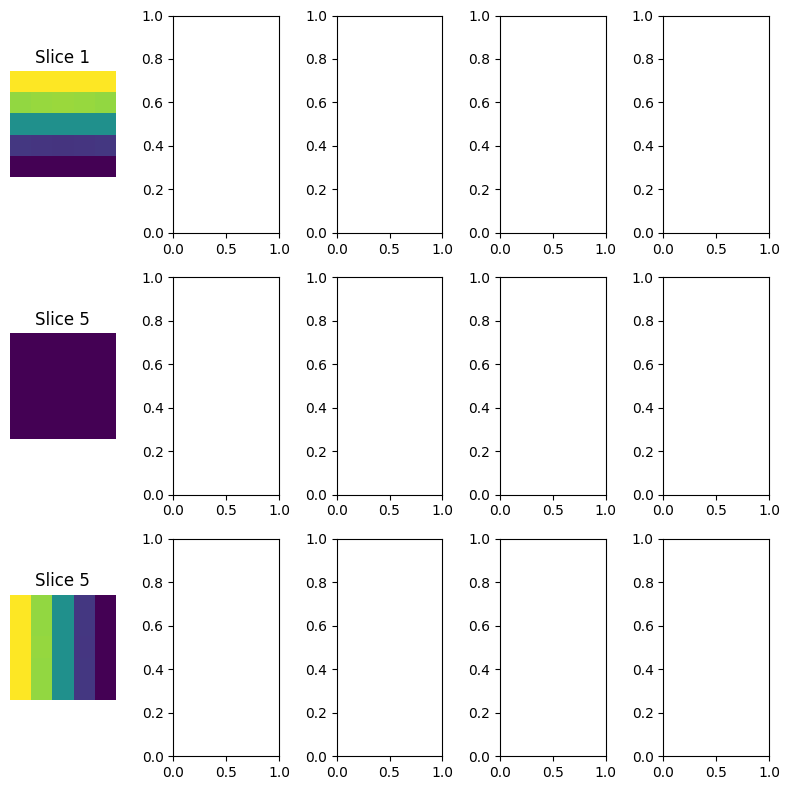

In [16]:
print(raveled_solution.min(), raveled_solution.max())
plt_show(raveled_solution, 4)

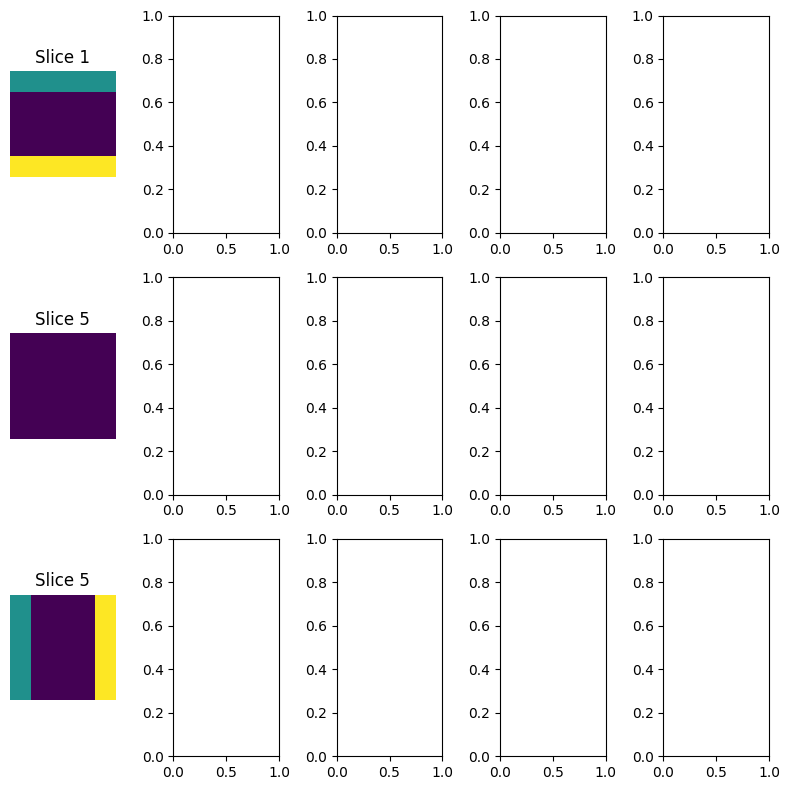

In [17]:
plt_show(vol, 4)

In [18]:
pressure_field = raveled_solution
x_pressure_gradient = np.zeros_like(pressure_field)
x_pressure_gradient[1:, :, :] -= x_pressure_gradient[:-1, :, :]
x_conductance = np.zeros_like(pressure_field)
x_conductance[1:, :, :] = 2/ (1/x_conductance[1:, :, :] + 1/x_conductance[:-1, :, :])
x_speed = x_pressure_gradient * x_conductance

0.0 0.0


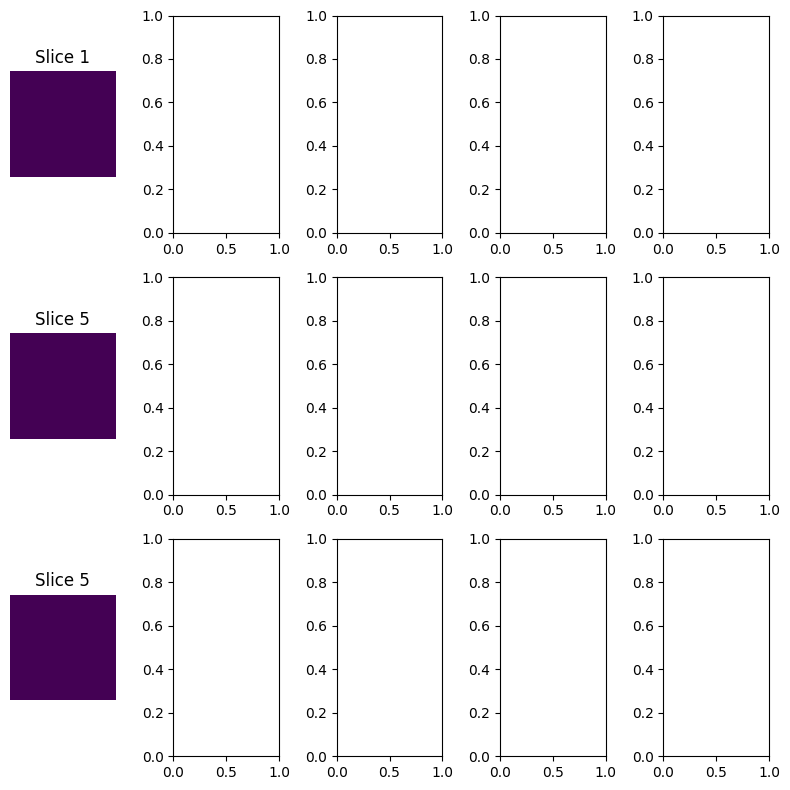

In [19]:
print(x_speed.min(), x_speed.max())
plt_show(x_speed, 4)